# Обобщенные линейные модели

**Обобщенные линейные модели **(generalized linear model, GLM), как следует из названия, обобщают и систематизируют наше понимание различных линейных моделей, к которым, например, относятся линейная и логистическая регрессия.
### Обыкновенная линейная регрессия

Еще раз рассмотрим модель обыкновенной линейной регрессии (ordinary
linear regression)

$$ y = \beta_0 + \beta_1x + \varepsilon, \varepsilon \sim \mathcal{N} (0, \sigma^2), $$

где, помимо других допущений:
* отклонение истинного значения $y$ от прогнозного $\hat{y}$ нормально
распределено;
* между предикторами и целевой переменной существует прямая линейная
зависимость.

![](https://drive.google.com/uc?export=view&id=1KVqEkdITHH9R94s9Afv0DXNU9vIJ2RSK)

Такие допущения оправданы, если мы моделируем некоторый непрерывный
количественный признак, например, рост человека.

При этом модель линейной регрессии можно задать и так.

$$ y \mid x \sim \mathcal{N} (\beta_0 + \beta_1x, \sigma^2) $$

В самом деле, для каждого значения $x$ среднее значение соответствующего
нормального распределения определяется как $\mu = \beta_0 + \beta_1x.$

Заметим, что нормальное распределение определяется не только средним, но и
дисперсией, которая, впрочем, не влияет на поиск оптимальных параметров
$\beta_j.$

### Регрессия Пуассона
Теперь предположим, что нам необходимо смоделировать счетные данные (count
data). Например, зависимость количества ДТП от времени суток.

![](https://drive.google.com/uc?export=view&id=1bKKNxiuWGQM4-x0Vcyx7VluXKJy4oNCy)

Попробуем допустить, что целевая переменная каждого наблюдения следует
распределению Пуассона.

$$ y \mid x \sim Poisson(\lambda) $$

Это разумно, поскольку именно распределение Пуассона используется для оценки
вероятности частоты событий с матожиданием $\lambda$ и имеет дискретный
носитель. Попробуем предсказать $\lambda$ с помощью линейной модели.

$$ y \mid x \sim Poisson(\beta_0 + \beta_1x) $$

К сожалению, линейная модель допускает отрицательные значения, при этом
очевидно, что среднее количество ДТП не может быть отрицательным.

### Функция связи
Введем **функцию связи** $g$ (link function), которая будет ограничивать диапазон
возможных значений $\lambda$

$$ g(\lambda) = \beta_0 + \beta_1x $$

Например, возведем прогнозные значения линейной модели в квадрат

$$\lambda=(\beta_0 + \beta_1x)^2$$

и тогда функцией связи $g$ будет функция квадратного корня

$$\sqrt{\lambda} = \beta_0 + \beta_1x$$

При этом для преобразования значения линейной модели в параметр выбранного
распределения лучше использовать так называемую **каноническую функцию
связи** (canonical link function).

В случае распределения Пуассона, канонической функцией связи будет функция
логарифма **(log link)**.

$$ \log(\lambda) = \beta_0 + \beta_1x $$

Соответственно, значение $\lambda$ можно найти через

$$ \lambda = \exp (\beta_0 + \beta_1x) $$

$$ y \mid x \sim Poisson(\exp (\beta_0 + \beta_1x)) $$

Заметим, что в модели линейной регрессии функцией связи будет **тождественная
функция** (identity function) $g(u)=u.$

## Структура обобщенной линейной модели
Таким образом, обобщенная линейная модель будет включать три составляющих:
* случайный компонент (random component) — выбранное распределение;
* систематический компонент (systematic component) — линейную
зависимость; и
* функцию связи.

### Экспоненциальное семейство распределений
Обсудим, почему функция логарифма является канонической функцией связи для
распределения Пуассона.

Можно сказать, что функция связи $g$ позволяет соединить математическое
ожидание $\mathbb{E}(y \mid x)$ выбранного распределения с линейным
систематическим компонентом $\beta_0 + \beta_1x$

$$ g(\mathbb{E}(y \mid x)) = \beta_0 + \beta_1x, $$

при этом прогноз для нового объекта $x$ задается через

$$ \hat{y} = \mathbb{E}(y \mid x) = g^{-1}(\beta_0 + \beta_1x) $$

В случае если выбранное распределение относится к **экспоненциальному
семейству распределений**  (exponential family of distributions), у нас есть
возможность связать линейную зависимость, обозначим ее через параметр $\theta,$
с матожиданием $\mathbb{E}(y \mid x)$

$$ g(\mathbb{E}(y \mid x)) = \theta $$

Экспоненциальное семейство включает те распределения, которые можно
параметризовать через канонический (canonical) или натуральный (natural)
параметр $\theta$ следующим образом:

$$ P(y \mid \theta) = h(y)\exp \left[ g(\theta)^\top T(y)-A(g(\theta)) \right] $$
### Нормальное распределение
В экспоненциальной форме одномерное нормальное распределение можно записать
так:

$$ \begin{split} P(y \mid \mu, \sigma^2) =& \; \frac{1}{\sqrt{2\pi}\sigma} \exp \left[ - \frac{1}{2\sigma^2}(y-\mu)^2 \right] \\ =& \; \frac{1}{\sqrt{2\pi}} \exp \left[ \frac{\mu}
{\sigma^2}y-\frac{1}{2\sigma^2}y^2-\frac{1}{2\sigma^2}\mu^2-\log \sigma \right],
\end{split} $$

где:

$$ \begin{split} \theta =& \; \begin{bmatrix} \mu / \sigma^2 \\ -1 / 2\sigma^2
\end{bmatrix} \\ T(y) =& \; \begin{bmatrix} x \\ x^2 \end{bmatrix} \\ A(\theta) =& \;
\frac{\mu^2}{2\sigma^2} + \log \sigma = -\frac{\theta^2_1}{4\theta_2}-\frac{1}
{2}\log(-2\theta_2) \\ h(y) =& \; \frac{1}{\sqrt{2\pi}} \end{split} $$

При фиксированном $\sigma^2$ тождественная функция $g(\mu)=\mu$
действительно напрямую связывает линейный компонент $\theta$ с матожиданием
нормального распределения $\mu.$

### Распределение Пуассона
Рассмотрим распределение Пуассона.

$$ P(y \mid \lambda) = \frac{\lambda^ye^{-\lambda}}{y!} $$

В экспоненциальной форме:

$$ P(y \mid \lambda) = \frac{1}{y!} \exp \left[ y \log \lambda-\lambda \right], $$

где:

$$ \begin{split} \theta =& \; \log \lambda \\ T(y) =& \; y \\ A(\theta) =& \; \lambda =
\exp{\theta} \\ h(y) =& \; \frac{1}{y!} \end{split} $$

Несложно увидеть, что $g(\lambda) = \log \lambda$ и $\lambda = g^{-1}(\theta) =
\exp{\theta}.$

## Бинарная логистическая регрессия
В бинарной логистической регрессии (binary logistic regression) прогнозная
случайная величина следует распределению Бернулли или, что то же самое,
биномиальному распределению с параметром $n=1.$

$$ y \mid x \sim Bern(\pi) $$

Например, мы можем моделировать вероятность возвращения кредита на основе
возраста заемщика.

![](https://drive.google.com/uc?export=view&id=1LCNj-Gsu0sclUdTKYVmOnjO0q6f3hJ5e)

Посмотрим, какая функция связи подходит для распределения Бернулли.
Определим функцию вероятности и перепишем ее в экспоненциальной форме:

$$ \begin{split} P(y \mid \pi) =& \; \pi^y(1-\pi)^{(1-y)} \\ =& \; \exp \left[ \log \left(
\frac{\pi}{1-\pi} \right) y + \log(1-\pi) \right], \end{split} $$

где:

$$ \begin{split} \theta =& \; \frac{\pi}{1-\pi} \\ T(y) =& \; y \\ A(\theta) =& \; -\log(1-
\pi)=\log(1+\exp \theta) \\ h(y) =& \; 1 \end{split} $$

Таким образом, $g(\pi)=\log \frac{\pi}{1-\pi}, \pi \in \{0,1\},$ является логит функцией, а

$$ \pi = g^{-1}(\theta) = \frac{1}{1+\exp(-\theta)} $$

представляет собой логистическую функцию (logistic function) или сигмоиду
(sigmoid).

Сделаем два дополнительных комментария.

**Логарифм шансов.** Логит функцию также называют логарифмом шансов (log
odds). Интересно, что если вероятность $\pi \in [0,1],$ то шансы могут быть любым
неотрицательным числом, $odds \in [0, \infty)$.

Например, при вероятности $0{,}75,$ шансы того, что событие произойдет, равны $
odds = \frac{0{,}75}{1-0{,}75} = \frac{3}{1} = 3.$ При вероятности $0{,}99,$ шансы
равны $99.$

Взятие логарифма позволяет сделать областью определения все действительные
числа $\mathbb{R}.$ Одновременно логарифм шансов симметричен относительно
нуля при вероятности $\pi=0{,5}$, $\log \left( \frac{0{,}5}{1-0{,}5} = 0 \right).$

Обратная к ней функция, сигмоида, выдает вероятность $0{,}5$ в случае, если
систематический компонент выдает ноль.

**Серия испытаний**. Целевая переменная может представлять собой вероятность
$1,2,\ldots,k$ успехов в $n$ испытаниях.

Например, речь может идти о вероятности успешного ответа $1,2,\ldots,10$
вопросов теста в зависимости от потраченного на учебу времени. В этом случае
целевая переменная следует биномиальному распределению с параметром $n=10.$

$$y \mid x \sim Binom(n=10, \pi)$$

На практике, можно применить тот же подход, что и для дихотомической целевой
переменной, дополнительно умножив предсказанное значение $\pi$ на число
испытаний $n.$

Например, если модель при восьми часах подготовки предсказывает вероятность успешного ответа на экзамене, равную $0{,}3,$ то мы можем предсказать, что
получится правильно ответить на три вопроса из десяти.

## Мультиномиальная логистическая регрессия
В случае многоклассовой классификации целевая переменная следует
мультиномиальному распределению

$$ y \mid x \sim Multinomial(\pi) $$

с функцией вероятности случайной величины $Y_i, i=1,\ldots,k$

$$ \begin{equation} P(y \mid \pi) =\frac{n!}{y_{1}!\dots y_{k}!}\pi_{1}^{y_{1}}\dots
\pi_{k}^{y_{k}}, \end{equation} $$

где $n \in \mathbb{N}$ — количество испытаний, $y_i \in \mathbb{N}$ — $i$-ое
событие в серии из $n$ испытаний и $\pi_i \in [0,1].$ При этом

$$ \sum^{k}_{i=1}y_{i}=n, \quad \sum^{k}_{i=1}\pi_{i}=1 $$

Покажем, что мультиномиальное распределение относится к экспоненциальному
семейству. С учетом того, что $\pi_k = 1-\sum^{k-1}_{i=1} \pi_i,$

$$ \begin{align} P(y \mid \pi) &= \frac{n!}{y_{1}!\dots y_{k}!} \pi_{1}^{y_{1}} \dots
\pi_{k}^{y_{k}} \\ &=\left(\frac{n!}{y_{1}! \dots y_{k}!} \right) \pi_{1}^{y_1} \dots
\pi_{k}^{1-\sum_{i=1}^{k-1}y_{i}} \\ &= \left(\frac{n!}{y_{1}! \dots
y_{k}!}\right)\exp\left[y_{1}\log \pi_{1}+\dots+\left(1-\sum_{i=1}^{k-
1}y_{i}\right)\log \pi_{k}\right] \\ &= \left(\frac{n!}{y_{1}!\dots y_{k}!}\right)\exp
\Bigg[ y_{1}\log \left(\frac{\pi_1}{\pi_{k}}\right)+\dots+y_{k-1}\log\left(\frac{\pi_1}
{\pi_{k-1}}\right) \\ &\hspace{0.7cm}+\log \pi_{k} \Bigg] \\ &=h(y_{1},\dots
,y_{k})\exp\left[\theta^{T}T(y_{1},\dots ,y_{k})-A(\theta)\right] \end{align}, $$

где:

$$ \begin{align} \theta &= \begin{bmatrix} \log(\pi_{1} / \pi_{k}) \\
\log(\pi_{2}/\pi_{k}) \\ \vdots \\ \log(\pi_{k-1}/ \pi_{k}) \end{bmatrix} \\ T(y_{1},\dots
,y_{k})&= \begin{bmatrix} y_{1} \\ y_{2} \\ \vdots \\ y_{k} \end{bmatrix} \\ A(\theta)
&=-\log \pi_{k} \\ h(y_{1},\dots ,y_{k})&=\frac{n!}{y_{1}!\dots y_{k}!}. \end{align}
$$

Таким образом, если $\theta_i = g(\pi_i) = \log \left( \frac{\pi_i}{\pi_k} \right)$
представляет собой мультиномиальную логит функцию, то обратная к ней

$$ \pi = g^{-1}(\theta) = \frac{\exp(\theta_k)}{\sum^k_{j=1} \exp(\theta_j)} $$

известна как многопеременная логистическая функция или softmax.

## Оптимальные параметры
Оптимальные параметры можно найти аналитически методом максимального
правдоподобия или используя численные методы и, в частности,
метод наименьших квадратов с итеративным пересчётом весов (iteratively
reweighted least squares, IRLS).
## Библиотека Statsmodels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_blobs
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score

In [ ]:
random_state = 42

## Линейная регрессия
Обучим модель линейной регрессии с помощью класса OLS (ordinary least squares)
и класса GLM библиотеки Statsmodels.

Подготовим синтетические данные.

In [ ]:
n_samples = 100
n_features = 2
bias = 10

X, y, coef = make_regression(n_samples=n_samples,
                             n_features=n_features,
                             bias=bias,
                             noise=20,
                             coef=True,
                             random_state=random_state)

Посмотрим на параметры, которые мы хотим предсказать.

In [ ]:
coef, bias

(array([87.73730719, 74.07686178]), 10)

Дополнительно преобразуем данные в датафрейм.

In [ ]:
linear_regression_data = pd.DataFrame({'X1': X[:,0], 'X2': X[:,1], 'y': y})

Заметим, что в statsmodels модель можно задать двумя способами:
* через statsmodels.api и
* через statsmodels.formula.api.

В первом случае, как и в случае библиотеки Sklearn, мы передаем модели
**эндогенную** (endogenous), т.е. зависимую и **экзогенные** (exogenous) или
независимые переменные.

In [ ]:
#import statsmodels.api as sm
sm.OLS(endog=y, exog=X).fit()

Во втором случае можно определить так называемую формулу, связывающую
эндогенную и экзогенные переменные, а также указать данные, в которых эти
переменные содержатся.
Такой

In [ ]:
#import statsmodels.formula.api as smf
smf.ols(formula='y ~ X1 + X2', data=linear_regression_data).fit()

Такой подход близок к API, используемому в языке R. Кроме этого обратим
внимание, что классы, использующие переменные, обозначаются заглавными
буквами, а те, что используют формулу — строчными.

Одновременно для обыкновенной линейной регрессии мы можем использовать:
* класс OLS, передавая эндогенную и экзогенные переменные или используя
формулу; а также
* класс GLM с указанием того, что остатки следуют нормальному
распределению.

### Класс OLS

**OLS: statsmodels.api** Обучим модель и выведем результаты регрессионного
анализа.

In [ ]:
# для того чтобы получить оценку сдвига, необходимо добавить столбец из единиц
X_ones = sm.add_constant(X)
linreg_ols = sm.OLS(y, X_ones).fit()
print(linreg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1152.
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.55e-68
Time:                        15:00:39   Log-Likelihood:                -448.46
No. Observations:                 100   AIC:                             902.9
Df Residuals:                      97   BIC:                             910.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4327      2.199      4.744      0.0

**ols: statsmodels.formula.api.** Теперь используем api с формулой.

In [ ]:
# при использовании API с формулой добавлять фиктивную переменную не нужно
linreg_ols = smf.ols(formula='y ~ X1 + X2', data=linear_regression_data).fit()
print(linreg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1152.
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.55e-68
Time:                        15:00:57   Log-Likelihood:                -448.46
No. Observations:                 100   AIC:                             902.9
Df Residuals:                      97   BIC:                             910.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.4327      2.199      4.744      0.0

Поговорим подробнее про некоторые из полученных результатов.

**Степени свободы остатков.** Имея $n = 100$ наблюдений и $p = 2$ предиктора
без учета сдвига $\beta_0,$ у нас осталось $df_{residuals} = n-p-1 = 97$ степеней
свободы (degrees of freedom) остатков. При этом степени свободы модели равны
количеству независимых переменных $df_{model} = p = 2.$

Отклонения от прогнозных значений и отклонения от среднего Для
дальнейшего анализа найдем сумму квадратов отклонений фактических значений от прогнозных (residual sum of squares)

$$ SS_{residuals} = \sum(y_i-\hat{y}_i)^2 $$

In [ ]:
# sum of squared residuals
np.sum(linreg_ols.resid ** 2), linreg_ols.ssr

(np.float64(46005.49837010103), np.float64(46005.49837010103))

Это та дисперсия, которую наша модель не объясняет. Также найдем сумму
квадратов отклонений прогнозных значений от среднего фактических данных или
объясненную дисперсию (explained sum of squares)

$$ SS_{explained} = \sum(\hat{y}_i-\bar{y})^2 $$

In [ ]:
# explained variance sum of squares
np.sum(np.square(linreg_ols.fittedvalues-np.mean(y))), linreg_ols.ess

(np.float64(1092881.16069544), np.float64(1092881.1606954413))

Наконец, общая дисперсия (total sum of squares) рассчитывается как сумма
квадратов отклонений фактических данных от их среднего значения

$$ SS_{total} = \sum(y_i-\bar{y})^2 $$

In [ ]:
# total sum of squares
np.sum(np.square(y-np.mean(y))), linreg_ols.centered_tss

(np.float64(1138886.6590655423), np.float64(1138886.6590655423))

или, что то же самое, сумму $SS_{residuals}$ и $SS_{explained}.$

In [ ]:
linreg_ols.ssr + linreg_ols.ess

np.float64(1138886.6590655423)

$R^2$ и скорректированный $R^2$  На приведенных выше показателях
основывается такой критерий **степени согласия** (goodness of fit) модели (т.е. ее
способности представлять наблюдаемые данные), как коэффициент детерминации
или $R^2.$ Он показывает долю объясненной изменчивости данных.

$$ R^2 = \frac{SS_{explained}}{SS_{total}} = 1-\frac{SS_{residuals}}{SS_{total}} $$

In [ ]:
r_squared = linreg_ols.ess / linreg_ols.centered_tss
r_squared

np.float64(0.959604849170989)

In [ ]:
r_squared = 1 - linreg_ols.ssr / linreg_ols.centered_tss
r_squared

np.float64(0.959604849170989)

Наконец скорректированный коэффициент детерминации понижает степень
согласия с увеличением количества признаков.

$$ R^2_{adj} = 1-\frac{(1-R^2)(n-1)}{n-p-1} $$

In [ ]:
adjusted_r_squared = 1 - (1 - r_squared) * (n_samples - 1) / (n_samples - n_features - 1)
adjusted_r_squared

np.float64(0.9587719594631743)

**f-критерий** (f-test) позволяет определить, насколько хорошо независимые
переменные *совместно* объясняют целевую переменную (в случае простой
линейной регрессии и одного предиктора было бы достаточно t-критерия):
* если ни один из предикторов не объясняет зависимую переменную, то все
параметры должны быть равны нулю; это и будет нулевой гипотезой f-теста,
$H_0: \beta_1 = \beta_2 = \ldots = \beta_p = 0;$
* альтернативная гипотеза заключается в том, что по крайней мере один
параметр не равен нулю, $H_1: \beta_j \neq 0.$

f-критерий сравнивает количество дисперсии, объясненной моделью с количеством
необъясненной дисперсии. Найдем F-статистику

$$ F = \frac{\frac{SS_{explained}}{df_{model}}}{\frac{SS_{residuals}}
{df_{residuals}}} = \left( \frac{\frac{SS_{explained}}{SS_{total}}}{p} \right) / \left(
\frac{\frac{SS_{residuals\vphantom{p}}}{SS_{total}}}{n-p-1} \right) = \left(
\frac{R^2}{p} \right) / \left( \frac{1-R^2}{n-p-1} \right) $$

In [ ]:
df_model = n_features
df_resid = n_samples - n_features - 1

F = (linreg_ols.ess / df_model) / (linreg_ols.ssr / df_resid)
F

np.float64(1152.139161004648)

Числитель, $SS_{explained},$ и знаменатель, $SS_{residuals},$ приведенной выше
формулы следуют распределению $\chi^2,$ каждое со своими степенями свободы
$df_{model}$ и $df_{residuals}$ соответственно. Отношение этих распределений
представляет собой F-распределение с теми же степенями свободы.

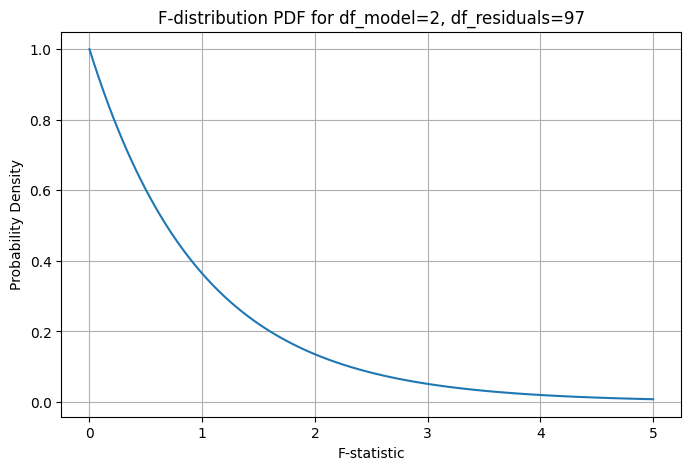

In [ ]:
from scipy.stats import f
x_fdist = np.linspace(0, 5, 120)
y_fdist = f.pdf(x_fdist, df_model, df_resid)

plt.figure(figsize=(8, 5))
plt.plot(x_fdist, y_fdist)
plt.title(f'F-distribution PDF for df_model={df_model}, df_residuals={df_resid}')
plt.xlabel('F-statistic')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

F-распределение позволяет оценить вероятность $H_0.$ В частности, поскольку это
односторонний тест, нас будет интересовать площадь под кривой справа от
F-статистики (однако уже на графике видно, что площадь справа от значения $F
\approx 1152{,}14$ чрезвычайно мала).

In [ ]:
p_value = f.sf(F, df_model, df_resid)
p_value

np.float64(2.55251234812177e-68)

При любом самом строгом пороговом значении, p-value окажется ниже. Как
следствие, мы можем отвергнуть нулевую гипотезу.

**Логарифм правдоподобия.** Помимо коэффициента детерминации степень
согласия можно оценить через логарифм максимального значения функции
правдоподобия.

Обратите внимание, здесь мы ищем именно максимальное значение функции
$\max \ell (\hat{\beta}),$ а не значение аргумента $ \operatorname{argmax} \ell
(\hat{\beta}),$ при котором функция правдоподобия достигает максимального
значения.

В самом деле, более высокие (менее отрицательные) значения $\ell$ говорят о том,
что модель лучше описывает данные.

Максимум логарифма правдоподобия можно найти по следующей формуле

$$ \max \ell (\hat{\beta}) = \log \hat{L} =-\frac{n}{2} \log 2\pi-\frac{n}{2} \log
\sigma^2-\frac{1}{2\sigma^2} \sum^n_{i=1} \varepsilon^2 $$

Заметим, что оптимальные $\hat{\sigma}^2$ и $\hat{\beta}$ нам уже известны. В
частности, коэффициенты $\hat{\beta}_j$ заложены в остатки $\varepsilon.$

In [ ]:
sigma_squared = linreg_ols.scale
error = linreg_ols.resid

In [ ]:
log_likelihood_terms = -0.5 * n_samples * np.log(2 * np.pi) - 0.5 * n_samples * np.log(sigma_squared) - 0.5 * np.sum(error**2) / sigma_squared
log_likelihood = np.sum(log_likelihood_terms)
log_likelihood

np.float64(-448.4841143009442)

In [ ]:
linreg_ols.llf

np.float64(-448.46115392670873)

**Выбор модели.** Логарифм правдоподобия удобно использовать, если нам нужно
выбрать между, например, *полной* или *длинной моделью* (full, unrestricted model),
т.е. такой моделью, которая использует все $\beta_j$ и некоторой вложенной
(nested) в нее *ограниченной* или *короткой* моделью (reduced, restricted model).

In [ ]:
# ограниченная модель, X2 = 0
restricted = smf.ols('y ~ X1', data=linear_regression_data).fit()

# полная модель
unrestricted = smf.ols('y ~ X1 + X2', data=linear_regression_data).fit()

In [ ]:
restricted.llf, unrestricted.llf

(np.float64(-575.9119363801976), np.float64(-448.46115392670873))

**Тест отношения правдоподобия** (likelihood ratio test, LR). Тестовую
статистику $\lambda_{LR}$ можно вычеслить через

$$ \lambda_{LR} = -2 \left( \frac{\hat{L}_R}{\hat{L}_F} \right) = -2 (\log \hat{L}_R-
\log \hat{L}_F), $$

где $\hat{L}_R$ и $\hat{L}_F$ — максимальное правдоподобие ограниченной и
полной модели соответственно.
* нулевая гипотеза $H_0$ теста утверждает, что короткой модели достаточно
для объяснения данных;
* альтернативная гипотеза $H_1$ предполагает, что длинная регрессия значимо
лучше подходит для моделирования данных.

В случае если верна $H_0,$ $\lambda_{LR}$ асимптотически при $n \rightarrow
\infty$ следует распределению $\chi^2 (q),$ где $q$ — число ограничений модели
(разница между степенями свободы полной и ограниченной модели).

In [ ]:
from scipy.stats import chi2
lambda_LR = -2 * (restricted.llf - unrestricted.llf)
print(lambda_LR)

254.9015649069778


In [ ]:
# найдем разницу в степенях свободы
df_diff = 2 - 1
# вычислим p-value
pvalue = 1 - chi2(df_diff).cdf(lambda_LR)
print(pvalue)

0.0


При этом, как правило, модели с бо́льшим количеством параметров склонны иметь
более высокие значения $\hat{L}.$ Кроме того, тест отношения правдоподобия
подходит только для вложенных моделей.

Для преодоления этих сложностей можно использовать так называемые
информационные критерии (information criteria).

**Информационный критерий Акаике** (Akaike information criterion, AIC)
рассчитывается по формуле

$$ AIC = -2 \log \hat{L} + 2 (p+1) $$

Другими словами, меньшее (положительное) значение критерия означает бо́льшую
степень согласия. Одновременно, AIC увеличивается с увеличением количества
коэффициентов $p.$

In [ ]:
p_restricted = 1
p_unrestricted = 2

In [ ]:
-2 * restricted.llf + 2 * (p_restricted + 1), -2 * unrestricted.llf + 2 * (p_unrestricted + 1)

(np.float64(1155.8238727603953), np.float64(902.9223078534175))

In [ ]:
restricted.aic, unrestricted.aic

(np.float64(1155.8238727603953), np.float64(902.9223078534175))

**Байесовский информационный критерий** (Bayesian information criterion, BIC)
или **критерий Шварца** (Schwarz information criterion, SIC)

$$ BIC = -2 \log \hat{L} + p \log n $$

сильнее, чем AIC «наказывает» за увеличение количества параметров модели.

In [ ]:
# рассчитаем BIC только для полной модели
-2 * unrestricted.llf + np.log(n_samples) * (p_unrestricted + 1)

np.float64(910.7378184113818)

In [ ]:
unrestricted.bic

np.float64(910.7378184113818)

### Класс GLM
Теперь применим класс GLM с традиционным API.

In [ ]:
linreg_glm = smf.glm(formula='y ~ X1 + X2', data=linear_regression_data,
                     family=sm.families.Gaussian()).fit()
print(linreg_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          474.28
Method:                          IRLS   Log-Likelihood:                -448.46
Date:                Tue, 25 Nov 2025   Deviance:                       46005.
Time:                        15:07:35   Pearson chi2:                 4.60e+04
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.4327      2.199      4.744      0.0

Здесь, в отличие от класса OLS, ожидаемо используется метод IRLS и появляются
новые способы оценить степень согласия.

Подробнее про эти показатели мы поговорим на примере другой модели —
логистической регрессии.

##Степень согласия

В обобщенной линейной модели для оценки степени согласия используется
**девианс** модели.

**Нулевая, предложенная и насыщенная модель.** Предположим, что на одних
и тех же данных мы построили три модели: нулевую, предложенную и
насыщенную:
* *нулевая (тривиальная) модель* (null model) строится только на основе
сдвига $\beta_0,$ все остальные $\beta_1, \ldots, \beta_p$ равны нулю; это самая
слабая из возможных моделей и лучшее, что можно сделать, это взять сдвиг
равный среднему значению, $\beta_0 = \bar{y};$
* *предложенная модель* (proposed model) — это та, которую мы обучили
выше. В ней есть сдвиг $\beta_0$ и два предиктора $\beta_1$ и $\beta_2;$
наконец
* *в насыщенной модели* (saturated model) количество параметров равно
количеству наблюдений за исключением сдвига $n-1;$ другими словами
модель идеально предсказывает каждый объект.



**Девианс** (deviance, residual deviance) рассчитывается как удвоенная разница между
максимальным правдоподобием насыщенной модели $\log \hat{L}_s$ и
максимальным правдоподобием предложенной модели $\log \hat{L}_p.$

$$ D = 2 (\log \hat{L}_s-\log \hat{L}_p) $$

Другими словами, мы оцениваем насколько хорошо предложенная модель
описывает данные по сравнению с «идеальной» насыщенной моделью.

**Нулевой девианс** (null deviance) показывает, насколько нулевая модель
«отстает» от насыщенной.

$$ D_{\text{null}} = 2 (\log \hat{L}_s-\log \hat{L}_0) $$

Можно показать, что девианс модели обыкновенной линейной регрессии
$D_{linear}$ аналогичен сумме разности квадратов отклонений прогнозных
значений от фактических.

$$ D_{\text{linear}} = SS_{residuals} = \sum_{i=1}^n (y_i-\hat{y}_i)^2 $$

Введем понятие **масштабированного девианса** (scaled deviance) $D^* =
\frac{D}{\phi},$ где $\phi$ — степень разброса (dispersion) случайной величины.

Для нормального распределения

$$ f(y; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(y-\mu)^2}
{2\sigma^2}\right) $$

масштабированный девианс одного наблюдения (unit deviance) равен

$$ \begin{align} D^{*}(y, \mu) &= 2l(y;y)-2l(\mu;y) \\ &= 2\log(f(y;y))-2\log(f(y;\mu))
\\ &= 2 \bigg[-\frac{1}{2}\log(2 \pi \sigma^2)-\frac{(y-y)^2}{2\sigma^2}\bigg]-2 \bigg[-
\frac{1}{2}\log(2 \pi \sigma^2)-\frac{(y-\mu)^2}{2\sigma^2}\bigg] \\ &= \frac{(y-
\mu)^2}{\sigma^2} \end{align} $$

Поскольку в нормальном распределении $\phi = \sigma^2,$

$$ D^{*}(y; \mu) = \frac{D(y; \mu)}{\phi} = \frac{D(y; \mu)}{\sigma^2} $$

$$ D(y, \mu) = (y-\mu)^2 $$





In [ ]:
np.sum(((y - linreg_glm.fittedvalues) ** 2)), linreg_glm.deviance

(np.float64(46005.49837010103), np.float64(46005.49837010103))

При этом нулевой девианс равен $SS_{total}.$

In [ ]:
np.sum(np.square(y-np.mean(y))), linreg_glm.null_deviance

(np.float64(1138886.6590655423), np.float64(1138886.6590655423))

*Коэффициент детерминации МакФаддена* (McFadden) рассчитывается через

$$ R^2_{\text{McF}} = 1-\frac{D}{D_0} = \frac{\log \hat{L}_p}{\log \hat{L}_0} $$

и показывает, насколько степень согласия предложенной модели близка к степень
согласия насыщенной или тривиальной модели (заметим, что псевдо-$R^2$ не стоит интерпретировать как долю объясненной дисперсии).

In [ ]:
1 - logreg_glm.deviance/logreg_glm.null_deviance, 1-logreg_glm.llf/logreg_glm.llnull

(np.float64(0.9259414511310167), np.float64(0.9259414511310168))

In [ ]:
logreg_glm.pseudo_rsquared(kind='mcf')

np.float64(0.9259414511310168)

Заметим, что в модели обыкновенной линейной регрессии коэффициент
МакФаддена очевидно аналогичен стандартному коэффициенту детерминации
$R^2.$

## Логистическая регрессия
Подготовим данные.

In [ ]:
n_samples = 200

X, y = make_blobs(n_samples=n_samples,
                  n_features=2,
                  centers=2,
                  cluster_std=2.8,
                  random_state=random_state)

logistic_regression_data = pd.DataFrame({'X1': X[:,0], 'X2': X[:,1], 'y': y})

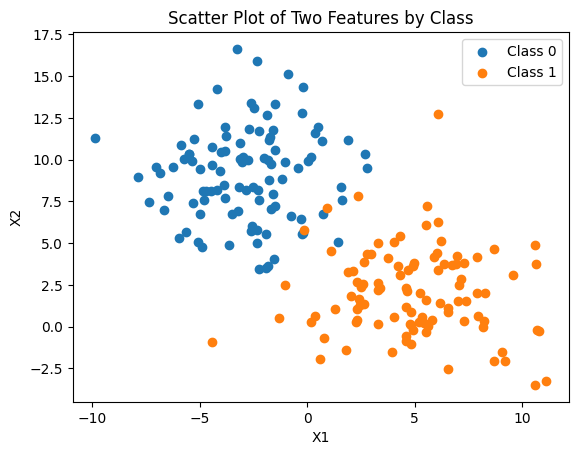

In [ ]:
fig, ax = plt.subplots()
for name, group in logistic_regression_data.groupby('y'):
    ax.scatter(group['X1'], group['X2'], label=f'Class {name}')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Scatter Plot of Two Features by Class')
ax.legend()
plt.show()

Масштабируем данные и добавляем фиктивный признак.

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = sm.add_constant(X)

Обучим логистическую регрессию или, что то же самое, обобщенную линейную
модель с биномиальным распределением остатков.

In [ ]:
logreg_glm = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(logreg_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      197
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10.267
Date:                Tue, 25 Nov 2025   Deviance:                       20.533
Time:                        15:16:59   Pearson chi2:                     24.6
No. Iterations:                    11   Pseudo R-squ. (CS):             0.7230
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0781      0.870      1.239      0.2

Сделаем прогноз и оценим accuracy.

In [ ]:
y_pred = logreg_glm.predict(X).round().astype(int)
accuracy_score(y, y_pred)

0.98

Найдем максимум логарифма правдоподобия

$$ \log \hat{L} = \sum \Big[ y_i \log \hat{y}_i + (1-y_i) \log(1-\hat{y_i}) \Big] $$

In [ ]:
np.sum(y * np.log(logreg_glm.fittedvalues) + (1 - y) * np.log(1 - logreg_glm.fittedvalues))

np.float64(-10.266694868979346)

In [ ]:
logreg_glm.llf

np.float64(-10.26669486897933)

Несложно вывести девианс модели логистической регресии $D_{logistic}.$

$$ \begin{align} D_{\text{logistic}} &= -2 \sum_{i=1}^n \Big[ y_i \log \hat{y}_i + (1-
y_i) \log (1-\hat{y}_i) \\ & \hspace{0.7cm}-y_i \log y_i-(1-y_i) \log (1-y_i) \Big] \\ &= -2
\sum_{i=1}^n \Big[ y_i \log \hat{y}_i + (1-y_i) \log(1-\hat{y_i}) \Big] \end{align} $$

In [ ]:
-2 * np.sum(y * np.log(logreg_glm.fittedvalues) + (1 - y) * np.log(1 - logreg_glm.fittedvalues))

np.float64(20.533389737958693)

Нулевой девианс логистической регрессии рассчитывается через

$$ D_{\text{null logistic}} = -2 \sum k \log \hat{p} + (n-k) \log (1-\hat{p}), $$

где $k$ — количество успехов, $n$ — количество наблюдений и $\hat{p} = \frac{k}
{n}$ — вероятность успеха на основе выборочных данных.

In [ ]:
k, n = np.sum(y), len(y)
p_hat = k/n

In [ ]:
-2 * np.sum(k * np.log(p_hat) + (n-k) * np.log(1-p_hat))

np.float64(277.25887222397813)

Сравним с показателями statsmodels.

In [ ]:
logreg_glm.deviance, logreg_glm.null_deviance

(np.float64(20.533389737958686), np.float64(277.2588722239781))

**Коэффициент детерминации** обобщенной линейной модели, также
называемый псевдо-$R^2$ (pseudo-$R^2$), яляется обобщением показателя $R^2$
для обыкновенной линейной регрессии.

Коэффициент детерминации МакФаддена (McFadden) рассчитывается через
$$ R^2_{\text{McF}} = 1-\frac{D}{D_0} = \frac{\log \hat{L}_p}{\log \hat{L}_0} $$
и показывает, насколько степень согласия предложенной модели близка к степень
согласия насыщенной или тривиальной модели (заметим, что псевдо-$R^2$ не стоит интерпретировать как долю объясненной дисперсии).

In [ ]:
1 - logreg_glm.deviance/logreg_glm.null_deviance, 1 - logreg_glm.llf/logreg_glm.llnull

(np.float64(0.9259414511310167), np.float64(0.9259414511310168))

In [ ]:
logreg_glm.pseudo_rsquared(kind='mcf')

np.float64(0.9259414511310168)

Заметим, что в модели обыкновенной линейной регрессии коэффициент
МакФаддена очевидно аналогичен стандартному коэффициенту детерминации
$R^2.$

In [ ]:
1 - (linreg_glm.deviance / linreg_glm.null_deviance)

np.float64(0.959604849170989)

Еще один *коэффициент детерминации Кокса и Снелла* (Cox and Snell, CS)

$$ \begin{align} R^2_{\text{CS}} &= 1-\left( \frac{\hat{L}_0}{\hat{L}_p}
\right)^{2/n} \\ &= 1-\exp \left( \frac{2}{n} \left( \log \hat{L}_0-\log \hat{L}_p \right)
\right) \end{align} $$

In [ ]:
1 - np.exp((logreg_glm.llnull - logreg_glm.llf)*(2/n_samples))

np.float64(0.7229694284920674)

In [ ]:
logreg_glm.pseudo_rsquared(kind='cs')

np.float64(0.7229694284920674)

Список литературы
* J. A. Nelder, R. W. M. Wedderburn, Generalized Linear Models , 1972;
* M. Jordan, Bayesian Modeling and Inference, chapter 8, 2009 (https://people.eecs.berkeley.edu/~jordan/courses/260-spring10/other-readings/chapter8.pdf);
* К.В. Воронцов, Лекции по алгоритмам восстановления регрессии (http://www.ccas.ru/voron/download/Regression.pdf), 2007;

## Дополнительные материалы

нулевая, предложенная и насыщенная модель

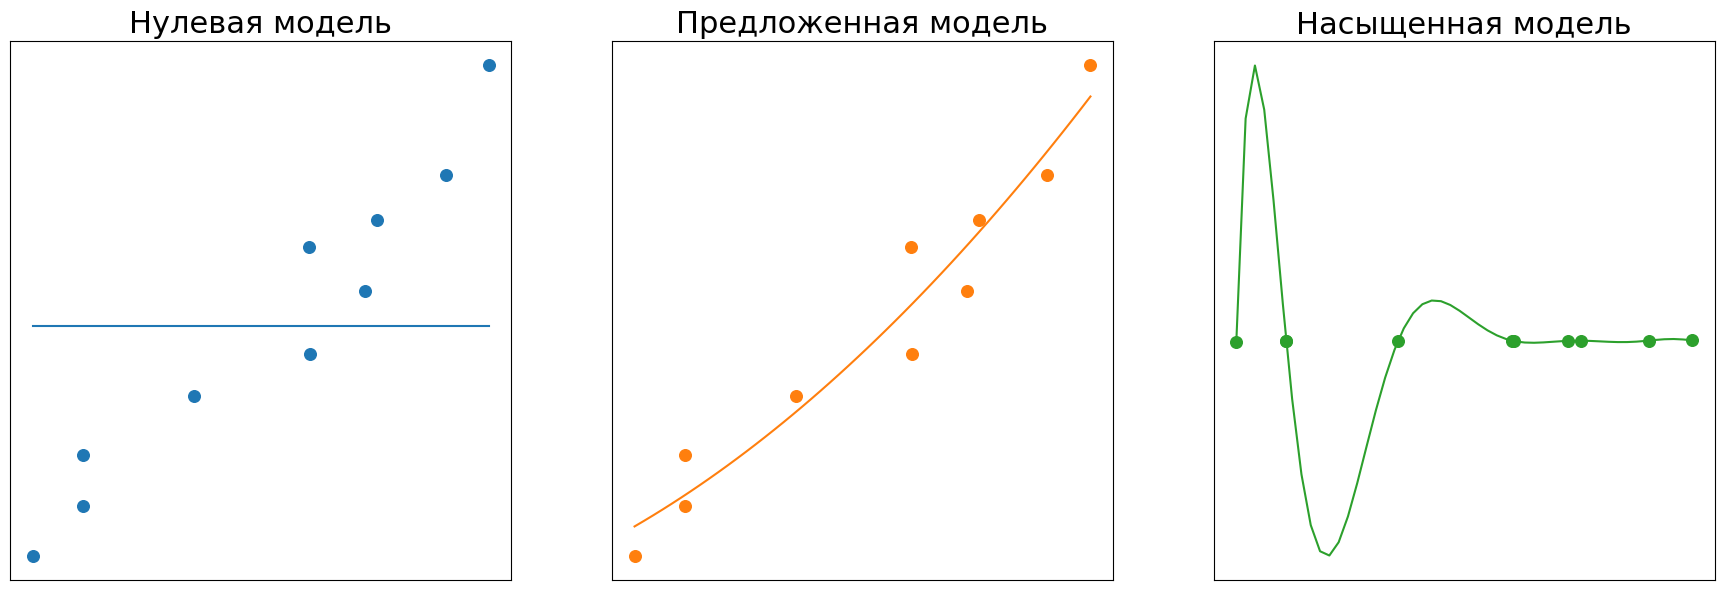

In [ ]:
# создадим искусственные данные
np.random.seed(42)
x = np.sort(np.random.rand(10) * 10)
y = 2 * x + np.random.randn(10) * 2 + 5

x_plot = np.linspace(min(x), max(x), 50)

# нулевая модель
null_coeff = np.polyfit(x, y, 0)
null_model = np.poly1d(null_coeff)
null_y = null_model(x_plot)

# предложенная модель
proposed_coeff = np.polyfit(x, y, 2)
proposed_model = np.poly1d(proposed_coeff)
proposed_y = proposed_model(x_plot)

# насыщенная модель
saturated_coeff = np.polyfit(x, y, len(x)-1)
saturated_model = np.poly1d(saturated_coeff)
saturated_y = saturated_model(x_plot)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22,7))
ax1.plot(x_plot, null_y, color='C0')
ax1.scatter(x,y,s=70, color='C0')
ax1.set_title('Нулевая модель', fontsize=22)
ax1.axes.xaxis.set_visible(False)
ax1.axes.yaxis.set_visible(False)
ax2.plot(x_plot, proposed_y, color='C1')
ax2.scatter(x,y,s=70, color='C1')
ax2.set_title('Предложенная модель', fontsize=22)
ax2.axes.xaxis.set_visible(False)
ax2.axes.yaxis.set_visible(False)
ax3.plot(x_plot, saturated_y, color='C2')
ax3.scatter(x,y,s=70, color='C2')
ax3.set_title('Насыщенная модель', fontsize=22)
ax3.axes.xaxis.set_visible(False)
ax3.axes.yaxis.set_visible(False)